## Pregunta
#### Contexto
> Del dataset breast cancer, cuya unidad de analisis es biopsia de tejidos mamarios. Cuyos features son 10 caracteristicas base, estas calculadas cada una de tres formas diferentes para un total de 30 caracteristicas. Cuyo target son 0, maligno; 1 benigno. Problema de clasificación binaria.
 
#### Pregunta de investigación
> ¿Utilizando el modelo SVM, es posible  predecir si un tumor es maligno o benigno?

## Unidad de análisis

#### Unidad
> Mediciones tomadas de una imagen digitaliada de una biopsia de tegido mamario aspirado con aguja fina. Cada registro o fila es un tumor.

#### Features
> 30 columnas que describen cada muestra. Las 30 featueres son derivadas de 10 features base, medidas de 3 formas distintas `(media, error estandard, y el peor valor o el valor mas extremo de las celulas).`
> Las 10 caracteristicas base son:

```
- radius (radio del núcleo celular)
- texture (variación en escala de grises)
- perimeter
- area
- smoothness
- compactness
- concavity
- concave points
- symmetry
- fractal dimension
```

#### Target 
El diagnostico del tumor se ha codificado como 0 o 1
```
- 0 -> maligno (canceroso)
- 1 -> benigno (no canceroso)
```

> Es un dataset de clasificacion binaria, pues debemos, en base al conjunto de datos, predecir si el tumor es maligno o benigno

## ⚠️Advertencia 

> El ejemplo no constituye diagnóstico médico. Es un caso de estudio para practicar el paso a paso con SVM con pipeline, búsqueda de parámetros y evaluación

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

In [ ]:
# importar y cargar datos
bunch = load_breast_cancer(as_frame=True)
X = bunch.data.copy()
y = bunch.target.copy()

print("shape")
print(X.shape)
print("----------------------------")
print(y.value_counts().sort_index())
print("----------------------------")
X.head()

shape
(569, 30)
----------------------------
target
0    212
1    357
Name: count, dtype: int64
----------------------------
<class 'pandas.Series'>
RangeIndex: 569 entries, 0 to 568
Series name: target
Non-Null Count  Dtype
--------------  -----
569 non-null    int64
dtypes: int64(1)
memory usage: 4.6 KB


In [ ]:
# Auditiar antes de modelar
audit = pd.DataFrame({
    "tipo": X.dtypes.astype(str),
    "ausentes": X.isna().sum(),
    "unicos": X.nunique()
})

print("Duplicados: ", X.duplicated().sum())
print("Target dentro de X: ", y.name in X.columns) #verify if the target is filtered into the features
audit.head(100)
"""
Why doing this audit:
- If the data types are text, then it would make the model not to work.
- If trere are nulls models like sklearn would fail
- By making sure we have unique rows, we avoid data leakage between train and test speration
"""

Duplicados:  0
Target dentro de X:  False


,tipo,ausentes,unicos
mean radius,float64,0,456
mean texture,float64,0,479
mean perimeter,float64,0,522
mean area,float64,0,539
mean smoothness,float64,0,474
mean compactness,float64,0,537
mean concavity,float64,0,537
mean concave points,float64,0,542
mean symmetry,float64,0,432
mean fractal dimension,float64,0,499


In [ ]:
# Reservar prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).round(3)) # this is going to compare how balance bouth set are
print(y_test.value_counts(normalize=True).round(3)) # this is going to compare how balance bouth set are

"""
random_state fija la semilla aleatoria, para que el proceso sea reproductible. De no hacerse asi, por cada corrida el modelo haria que se aleatoria
la division de entrenamiento y prueba

stratify=y le dice a la funcion que mantenga la misma proporcion de clases (0 y 1) tanto en train como en test que la que existen en el "y" original.
Es decir, hace un muestreo estratificado en vez de puramente aleatorio.


"""

(455, 30) (114, 30)
target
1    0.626
0    0.374
Name: proportion, dtype: float64
target
1    0.632
0    0.368
Name: proportion, dtype: float64


In [ ]:
# Crear una línea base
from sklearn.dummy import DummyClassifier # un modelo que no aprende de las features. Predice usando reglas triviales.
from sklearn.metrics import f1_score

dummy = DummyClassifier(strategy="most_frequent") # siempre predice la clase mayoritaria
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
print("F1 macro baseline:", f1_score(y_test, dummy_pred, average="macro"))

"""
average="macro" le dice al f1_score que calcule el f1 para cada clase por separado y luego lo promedie

"""

F1 macro baseline: 0.3870967741935484


In [ ]:
# Construir la SVM correctamente
from sklearn.pipeline import Pipeline #It allows to chain different steps into a single object, like: processing + model. This will guarantee order
#execution 
from sklearn.preprocessing import StandardScaler #tools that standarize the features. Since SVM is sensble to big quantities, this parameter help to
# transform all the features to having main as 0 and standard desviation as 1. This help SVM treat all feature as comparable into the same scale
from sklearn.svm import SVC #Support Vector Clasifier.

svm = Pipeline([
    ("scale", StandardScaler()), # first step of the pipeline
    ("model", SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=42)) # second step of the pipeline
])
svm.fit(X_train, y_train) # the importnace of doing this in a pipeline, is because when we use this later, it will using same mean, and deviation
#standard. For example when we use this with the X_test portion, it wont be recalculating mean and std, it will guarantee execution with same mean and std
#this guarantee  reproductiveness

"""
- kernel="rbf": define como la SVM mide similitud entre puntos. "rbf" (Radial Basis Function), permite que los SVM encuentren fronteras de
decision no lineals entre clases (a diferencia de kernel="linear")
- C=1: el valor por defecto es 1. C bajo, es mas permisivo a errores; C alto, puede guiar a sobreajuste. 1 es intermedio
- gamma="scale": es un modo automatico para el gamma, permite calcular el gamaba basesado en la varianza. Si fuera alto puede hacer que cada punto se
enfoque en su vecino mas cercano, con bajo puede hacer que se amplie. En este caso "scale" hace esto de forma automatica.
-  probability=True: para que devuelva la probabilidad y no la clase
- probability=True: Eso garantiza que el nivel de radom para "probability=True" se mantenga
- svm.fit(X_train, y_train) ejecuta los pasos del pipeline, todo encapsulado
"""

d:\Documents\Ciencias de datos\Ciencia de datos 2\PRACTICAS\uasd-ds-2\unidad01\LAB01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114

ROC-AUC: 0.995


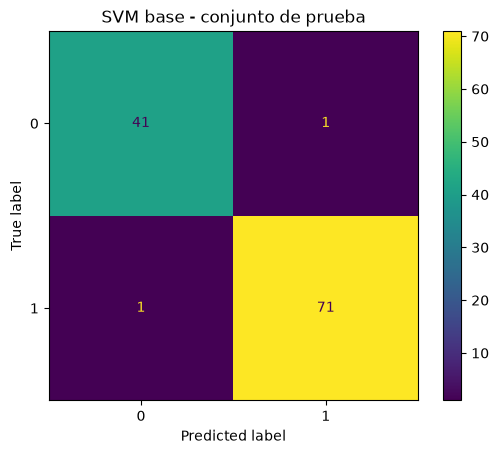

In [ ]:
# Evaluar la configuración base
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
import matplotlib.pyplot as plt

pred = svm.predict(X_test)
proba = svm.predict_proba(X_test)[:, 1] # si anteriormente no hubisemos seteado el parametro "probability=True", esta linea daria error.
print(classification_report(y_test, pred, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.title("SVM base - conjunto de prueba")
plt.show()

"""
Cuenta falsos positivos y falsos negativos.
Explica cuál sería más costoso en el caso.
No selecciones hiperparámetros mirando esta matriz repetidamente

Pression (clase 0): De todos los que el modelo dijo "maligno", cuantos realmente eran malignos?
Recall (clase0): Te todos los malignos reales, cuantos detecto el modelo?
F1-score: balance entre precision y recall, por clase
Support: cuantos casos reales hay de esa clase en y_test

- digits=4: cauntos decimales mostrar 

El numeros mas importante es de la case 0 el Recall (maligno). Designa el falso negativo.
Si es de un 0.93, sinifica que el modelo deja un 7% de los malignos reales, clasificados como benignos. Ese numero requiere mas atencion que el
accuracy.


- macro avg: promedio simple entre las clases (mismo cálculo que hiciste con el baseline — comparalo con ese F1 macro ≈ 0.38 de antes)
- weighted avg: promedio ponderado según cuántos casos tiene cada clase (support)

ROC-AUC (Area Under the ROC Curve) responde, intuitivamente: si tomás un caso maligno al azar y uno benigno al azar, ¿qué probabilidad hay de que el modelo le asigne una probabilidad de "maligno" más alta al que realmente es maligno?
    - 1.0 → separación perfecta entre clases
    - 0.5 → el modelo no distingue mejor que tirar una moneda
    - Valores típicos "buenos" en este dataset suelen rondar 0.98-0.99+ (es un dataset donde los modelos suelen andar muy bien)


Resumen: ¿qué te dice este fragmento en conjunto?
Código	                Qué mide	                        Se enfoca en
classification_report	Precision, recall, F1 por clase	    Predicciones finales (0/1)
roc_auc_score	        Capacidad de separación general	    Probabilidades, no clases finales
ConfusionMatrixDisplay	Visualización de aciertos/errores	Dónde específicamente se equivoca el modelo    

Con estos tres resultados juntos, ya podés responder tu pregunta de investigación original: comparás el F1 macro del baseline (~0.38)
contra el F1 macro (o accuracy, o recall de clase 0) de esta SVM, y ahí tenés evidencia concreta de si el modelo aprendió algo útil
 — y específicamente, qué tan bien está evitando el error más peligroso (los falsos negativos en malignos).
"""


In [ ]:
#  Buscar C y gamma dentro del pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = GridSearchCV( #Al final, GridSearchCV identifica cuál combinación de C/gamma dio, en promedio sobre los 5 folds, el mejor f1_macro.
    estimator=svm,
    param_grid={
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", 0.01, 0.1]
    },
    scoring="f1_macro", cv=cv, n_jobs=-1, return_train_score=True
)
search.fit(X_train, y_train) #Esto dispara las 45 combinaciones de entrenamiento+validación
"""
Importante: después de este .fit(), por defecto GridSearchCV automáticamente vuelve a entrenar
un modelo final con la mejor combinación encontrada, ahora sí usando 
todo X_train (no solo 4/5 partes) — eso queda guardado en search.best_estimator_,
listo para usarse sobre X_test cuando quieras.
"""
print(search.best_params_)
print("CV:", round(search.best_score_, 4))

"""
- GridSearchCV: prueba todas las combinaciones posibles de hiperparámetros que le indiques, evaluando cada una con validación 
cruzada, y te dice cuál fue la mejor.
- StratifiedKFold: una forma de dividir los datos en validación cruzada que respeta las proporciones de clases
 en cada partición (igual concepto que stratify=y de antes, pero aplicado a validación cruzada en vez de a la división train/test).

 estimator=svm

Le pasás el pipeline completo que armaste antes (StandardScaler + SVC), no solo el SVC suelto.
Esto es importante: significa que en cada combinación probada, y en cada fold, el StandardScaler se vuelve 
a ajustar solo con los datos de entrenamiento de ese fold — evitando de nuevo cualquier fuga de información, ahora
también dentro del proceso de validación cruzada.

Se están probando:
    - C: [0.1, 1, 10] → 3 valores, desde más tolerante a errores (0.1) hasta más estricto/ajustado (10)
    - gamma: ["scale", 0.01, 0.1] → el modo automático que usaste antes, más dos valores numéricos fijos, de menor a mayor "influencia local"

Como son 3 valores de C × 3 valores de gamma = 9 combinaciones distintas en total. Y como cada una se evalúa con 5 folds (por el cv),
en total se entrena el modelo 9 × 5 = 45 veces.


- scoring="f1_macro": La métrica que se usa para decidir cuál combinación es "la mejor".

n_jobs=-1: -1 es la convención de sklearn para "usá todos los cores disponibles".

return_train_score=True

Además de guardar el score de validación (en los folds "de test" dentro de cada partición), también guarda el score 
obtenido en los folds "de entrenamiento". Esto te permite después comparar train vs validación para cada combinación,
y detectar sobreajuste (overfitting): si el score en train es mucho más alto que en validación para cierta combinación 
de C/gamma, es señal de que esa combinación memoriza en vez de generalizar. Por defecto este parámetro es False 
(no se calcula, para ahorrar tiempo), así que acá se lo está pidiendo explícitamente.

- search.best_params_ → un diccionario con la combinación ganadora, por ejemplo: {'model__C': 10, 'model__gamma': 0.01}.
- search.best_score_ → el f1_macro promedio (sobre los 5 folds) que logró esa mejor combinación, durante la validación 
cruzada — todavía no es el resultado sobre X_test

Punto importante para no confundir
Este número (search.best_score_) es el rendimiento estimado dentro de train, usando validación cruzada. No es la evaluación final. 
El paso lógico que sigue sería tomar search.best_estimator_ (el modelo ya reentrenado con todo X_train y los mejores hiperparámetros) 
y evaluarlo sobre X_test — con el mismo tipo de código que usaste en el fragmento anterior 
(classification_report, roc_auc_score, matriz de confusión) — para ver si mejoró respecto a la SVM base (C=1, gamma="scale") y,
por supuesto, respecto al baseline dummy.
"""

"""
X_train (80% del dataset)
       │
       ▼
StratifiedKFold divide en 5 folds
       │
       ▼
Por cada una de las 9 combinaciones (C × gamma):
   entrenar en 4 folds, validar en 1 fold → repetir 5 veces → promediar f1_macro
       │
       ▼
Elegir la combinación con mejor f1_macro promedio
       │
       ▼
Reentrenar automáticamente esa combinación con TODO X_train
       │
       ▼
search.best_estimator_ ← listo para evaluar sobre X_test
"""

{'model__C': 10, 'model__gamma': 0.01}
CV: 0.9739


d:\Documents\Ciencias de datos\Ciencia de datos 2\PRACTICAS\uasd-ds-2\unidad01\LAB01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [ ]:
# Comparar sin ocultar variación
cv_results = pd.DataFrame(search.cv_results_)
columns = ["param_model__C", "param_model__gamma",
           "mean_test_score", "std_test_score", "mean_fit_time"]
cv_results[columns].sort_values("mean_test_score", ascending=False).head(9)

best = search.best_estimator_
best_pred = best.predict(X_test)
print(classification_report(y_test, best_pred, digits=4)) #Mismo tipo de output que viste con la SVM base, pero ahora con el modelo ya optimizado.
"""
search.cv_results_ es un diccionario que GridSearchCV genera automáticamente con los resultados de las 9 combinaciones, no solo la mejor.
Convertirlo a DataFrame te lo deja en formato tabla, fácil de ordenar y filtrar — una fila por cada combinación de hiperparámetros probada.

- mean_test_score → el promedio del f1_macro sobre los 5 folds de validación
- std_test_score → la desviación estándar del score entre los 5 folds
- mean_fit_time → cuánto tiempo (en segundos) tardó en promedio cada entrenamiento con esa combinación.

- sort_values("mean_test_score", ascending=False) → ordena las filas de mayor a menor score promedio, para ver de un vistazo cuáles 
combinaciones funcionaron mejor.
"""

"""
Ahora sí — esta es la primera vez en todo este proceso de búsqueda de hiperparámetros que tocás X_test. 
Todo lo anterior (los 45 entrenamientos, la elección del mejor C/gamma) ocurrió exclusivamente 
dentro de X_train, vía validación cruzada. Esto es exactamente lo que se busca:
mantener X_test "guardado" para una evaluación final honesta, no contaminada por el proceso de selección de hiperparámetros


------------------------------------------------------------------------------------
Modelo	                        Qué representa
Dummy baseline	                ~0.38 F1 macro — el piso, sin aprender nada
SVM base (C=1, gamma="scale")	Tu primer modelo real, sin optimizar
SVM optimizada (best)	        Con los mejores C/gamma encontrados por búsqueda
------------------------------------------------------------------------------------
"""


              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



In [ ]:
#Llevar código reutilizable a src


In [ ]:
# Guardar resultados y versionar
from pathlib import Path
import joblib
Path("../reports").mkdir(exist_ok=True)
cv_results[columns].to_csv("../reports/svm_cv_results.csv", index=False) #Toma el DataFrame que armaste en el fragmento anterior (las 9 combinaciones de C/gamma con sus scores) y lo guarda como un archivo CSV dentro de la carpeta que acabás de crear.
joblib.dump(best, "../reports/svm_best.joblib") #Guardar el modelo entrenado

"""
¿Por qué guardar esto? Para tener un registro reproducible del experimento de búsqueda de hiperparámetros — 
podés volver a mirarlo después (o compartirlo con alguien más) sin tener que correr de nuevo los 45 entrenamientos.
"""

"""
Esto es clave porque significa que no tenés que volver a entrenar el modelo cada vez que lo necesites. Podés cargarlo después con:

best_reloaded = joblib.load("../reports/svm_best.joblib")
best_reloaded.predict(X_nuevos_datos)

Y como guardaste el pipeline completo (no solo el SVC suelto), el StandardScaler con sus parámetros ya aprendidos
(media y desviación de X_train) viaja incluido — no tenés que acordarte de re-aplicar el escalado por separado,
ni correr el riesgo de escalarlo mal o con parámetros distintos a los originales.
"""

['../reports/svm_best.joblib']

In [ ]:
"""
Datos crudos (X, y)
   │
   ▼
Auditoría (tipos, nulos, duplicados, leakage)
   │
   ▼
Train / Test split (estratificado)
   │
   ▼
Baseline (DummyClassifier) → piso de referencia
   │
   ▼
SVM base (Pipeline: scaler + SVC) → primer modelo real
   │
   ▼
Evaluación base (classification_report, ROC-AUC, matriz de confusión)
   │
   ▼
GridSearchCV + StratifiedKFold → busca mejores C y gamma
   │
   ▼
Evaluación del mejor modelo sobre X_test
   │
   ▼
Guardar resultados (CSV) y modelo (joblib) ← ESTE FRAGMENTO
"""